# Модуль 7. Очистка данных

9/12   Закрепление знаний


✍️ Настало время потренироваться в очистке данных! В этот раз тема особенно важная — поговорим о диабете.

Вам предоставлен набор данных, первоначально полученный в Национальном институте диабета, болезней органов пищеварения и почек. 

Этот набор данных создан для того, чтобы на основе определённых диагностических измерений предсказать, есть ли у пациента диабет. 

На выбор этих экземпляров из более крупной базы данных было наложено несколько ограничений. В частности, все пациенты здесь — женщины не моложе 21 года индейского происхождения Пима.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
df_data = pd.read_csv('data/diabetes_data.csv')

In [37]:
df = df_data.copy()

In [38]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Gender
0,6,98,58,33,190,34.0,0.430,43,0,Female
1,2,112,75,32,0,35.7,0.148,21,0,Female
2,2,108,64,0,0,30.8,0.158,21,0,Female
3,8,107,80,0,0,24.6,0.856,34,0,Female
4,7,136,90,0,0,29.9,0.210,50,0,Female


Pregnancies — количество беременностей.

Glucose — концентрация глюкозы в плазме через два часа при пероральном тесте на толерантность к глюкозе.

BloodPressure — диастолическое артериальное давление (мм рт. ст.).

SkinThickness — толщина кожной складки трицепса (мм).

Insulin — двухчасовой сывороточный инсулин (ме Ед/мл).

BMI — индекс массы тела ($\frac{вес\ в\ кг}{(рост\ в\ м)^2}$).

DiabetesPedigreeFunction — функция родословной диабета (чем она выше, тем выше шанс наследственной заболеваемости).

Age — возраст.

Outcome — наличие диабета (0 — нет, 1 — да).

Предварительно вы можете провести небольшой разведывательный анализ: посмотреть на распределения признаков и оценить их взаимосвязь с признаком наличия диабета.

**Задание 8.1**

Начнём с поиска дубликатов в данных. Найдите все повторяющиеся строки в данных и удалите их. Для поиска используйте все признаки в данных. Сколько записей осталось в данных?

In [39]:
mask = df.duplicated()
df_duplicates = df[mask]
print(f'Число найденных дубликатов: {df_duplicates.shape[0]}')

df = df.drop_duplicates()
print(f'Результирующее число записей: {df.shape[0]}')

Число найденных дубликатов: 10
Результирующее число записей: 768


In [40]:
df_duplicates

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Gender
768,6,98,58,33,190,34.0,0.430,43,0,Female
769,2,112,75,32,0,35.7,0.148,21,0,Female
770,2,108,64,0,0,30.8,0.158,21,0,Female
771,8,107,80,0,0,24.6,0.856,34,0,Female
772,7,136,90,0,0,29.9,0.210,50,0,Female
773,6,103,72,32,190,37.7,0.324,55,0,Female
774,1,71,48,18,76,20.4,0.323,22,0,Female
775,0,117,0,0,0,33.8,0.932,44,0,Female
776,4,154,72,29,126,31.3,0.338,37,0,Female
777,5,147,78,0,0,33.7,0.218,65,0,Female


**Задание 8.2**

Далее найдите все неинформативные признаки в данных и избавьтесь от них. В качестве порога информативности возьмите 0.95: удалите все признаки, для которых 95 % значений повторяются или 95 % записей уникальны. В ответ запишите имена признаков, которые вы нашли (без кавычек).

Примечание: дальнейшая работа производится с очищенными от дубликатов и неинформативных признаков данных.

In [41]:
# зададим начальные значения
max_freq, max_nunique_ratio = 0.95, 0.95

# список неинформативных признаков
low_information_cols = [] 

# цикл по всем столбцам
for col in df.columns:
    # наибольшая относительная частота в признаке
    top_freq = df[col].value_counts(normalize=True).max()
    # доля уникальных значений от размера признака
    nunique_ratio = df[col].nunique() / df[col].count()
    # сравниваем наибольшую частоту с порогом
    if top_freq > max_freq:
        low_information_cols.append(col)
        print(f'{col}: {round(top_freq*100, 2)}% одинаковых значений')
    # сравниваем долю уникальных значений с порогом
    if nunique_ratio > max_nunique_ratio:
        low_information_cols.append(col)
        print(f'{col}: {round(nunique_ratio*100, 2)}% уникальных значений')

df = df.drop(low_information_cols, axis=1)
print(f'Результирующее число признаков: {df.shape[1]}')

Gender: 100.0% одинаковых значений
Результирующее число признаков: 9


**Задание 8.3**

Попробуйте найти пропуски в данных с помощью метода isnull().

Спойлер: ничего не найдёте. А они есть! Просто они скрыты от наших глаз. В таблице пропуски в столбцах Glucose, BloodPressure, SkinThickness, Insulin и BMI обозначены нулём, поэтому традиционные методы поиска пропусков ничего вам не покажут. Давайте это исправим!

Замените все записи, равные 0, в столбцах Glucose, BloodPressure, SkinThickness, Insulin и BMI на символ пропуска. Его вы можете взять из библиотеки numpy: np.nan.

Какая доля пропусков содержится в столбце Insulin? Ответ округлите до сотых.

In [42]:
df.isnull().any()

Pregnancies                 False
Glucose                     False
BloodPressure               False
SkinThickness               False
Insulin                     False
BMI                         False
DiabetesPedigreeFunction    False
Age                         False
Outcome                     False
dtype: bool

In [43]:
df[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']] = \
df[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']].replace(0, np.nan)

In [44]:
df[df['Insulin'].isnull() == True].shape[0] / df['Insulin'].shape[0]

0.4869791666666667

In [45]:
df['Insulin'].isna().mean()

0.4869791666666667

**Задание 8.4**

Удалите из данных признаки, где число пропусков составляет более 30 %. Сколько признаков осталось в ваших данных (с учетом удаленных неинформативных признаков в задании 8.2)?

In [46]:
cols_null_percent = df.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent > 0].sort_values(ascending=False)
display(cols_with_null)

Insulin          48.697917
SkinThickness    29.557292
BloodPressure     4.557292
BMI               1.432292
Glucose           0.651042
dtype: float64

Для удаления строк и столбцов будем использовать метод dropna(), который позволяет удалять пропуски с тонким подходом к настройке. 

Основные параметры метода:

* axis — ось, по которой производится удаление (по умолчанию 0 — строки).
* how — как производится удаление строк (any — если хотя бы в одном из столбцов есть пропуск, стоит по умолчанию; all — если во всех столбцах есть пропуски). 
* thresh — порог удаления. Определяет минимальное число непустых значений в строке/столбце, при котором она/он сохраняется. Например, если мы установим thresh в значение 2, то мы удалим строки, где число пропусков больше чем $n-2$, где $n$ — число признаков (если $axis=0$).

In [47]:
# создаем копию исходной таблицы
drop_data = df.copy()
# задаем минимальный порог: вычисляем 70% от числа строк
thresh = drop_data.shape[0] * 0.7
# удаляем столбцы, в которых более 30% (100-70) пропусков
drop_data = drop_data.dropna(thresh=thresh, axis=1)
# отображаем результирующую долю пропусков
drop_data.isna().mean()

Pregnancies                 0.000000
Glucose                     0.006510
BloodPressure               0.045573
SkinThickness               0.295573
BMI                         0.014323
DiabetesPedigreeFunction    0.000000
Age                         0.000000
Outcome                     0.000000
dtype: float64

In [48]:
drop_data.shape

(768, 8)

В итоге мы сбросили один параметр Insulin, мало о чём говорящий и с большим количество пропусков. Запишем результат в рабочую таблицу ```df```.

In [49]:
df = drop_data.copy()

**Задание 8.5**

Удалите из данных только те строки, в которых содержится более двух пропусков одновременно. Чему равно результирующее число записей в таблице?

In [50]:
# удаляем записи, в которых есть более двух пропусков

# задаем минимальный порог thresh
# Требует указания целого числа N. Оставляет только те строки/столбцы, у которых есть как минимум N непропущенных значений.

thresh = df.shape[1] - 2
thresh

6

In [51]:
df_dropped = df.dropna(thresh=thresh, axis=0)

df_dropped.shape, df.shape

((761, 8), (768, 8))

In [52]:
# Объединяем DataFrames с помощью merge, чтобы найти строки, которые есть только в исходном
rows_to_drop = df.merge(df_dropped, how='left', indicator=True)
rows_to_drop = rows_to_drop[rows_to_drop['_merge'] == 'left_only'].drop('_merge', axis=1)
rows_to_drop

,Pregnancies,Glucose,BloodPressure,SkinThickness,BMI,DiabetesPedigreeFunction,Age,Outcome
57,3,80.0,NaN,NaN,NaN,0.174,22,0
92,2,74.0,NaN,NaN,NaN,0.102,22,0
112,7,105.0,NaN,NaN,NaN,0.305,24,0
126,10,115.0,NaN,NaN,NaN,0.261,30,1
154,2,84.0,NaN,NaN,NaN,0.304,21,0
308,0,94.0,NaN,NaN,NaN,0.256,25,0
323,6,114.0,NaN,NaN,NaN,0.189,26,0


In [53]:
# записываем результат в рабочую таблицу
df = df_dropped

In [54]:
df.shape

(761, 8)

**Задание 8.6**

В оставшихся записях замените пропуски на медиану. Чему равно среднее значение в столбце SkinThickness? Ответ округлите до десятых.

In [55]:
# значение до изменений
df['SkinThickness'].mean()

29.153419593345657

In [56]:
mask = df.isna().any(axis=1)
df[mask]

,Pregnancies,Glucose,BloodPressure,SkinThickness,BMI,DiabetesPedigreeFunction,Age,Outcome
2,2,108.0,64.0,NaN,30.8,0.158,21,0
3,8,107.0,80.0,NaN,24.6,0.856,34,0
4,7,136.0,90.0,NaN,29.9,0.210,50,0
7,0,117.0,NaN,NaN,33.8,0.932,44,0
9,5,147.0,78.0,NaN,33.7,0.218,65,0
...,...,...,...,...,...,...,...,...
738,8,99.0,84.0,NaN,35.4,0.388,50,0
747,5,122.0,86.0,NaN,34.7,0.290,33,0
764,1,96.0,122.0,NaN,22.4,0.207,27,0
766,0,141.0,NaN,NaN,42.4,0.205,29,1


In [57]:
df['SkinThickness'].median()

29.0

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 761 entries, 0 to 767
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               761 non-null    int64  
 1   Glucose                   756 non-null    float64
 2   BloodPressure             733 non-null    float64
 3   SkinThickness             541 non-null    float64
 4   BMI                       757 non-null    float64
 5   DiabetesPedigreeFunction  761 non-null    float64
 6   Age                       761 non-null    int64  
 7   Outcome                   761 non-null    int64  
dtypes: float64(5), int64(3)
memory usage: 53.5 KB


In [59]:
# Заменяем pd.NA медианой для каждой колонки
df = df.fillna(df.median())

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 761 entries, 0 to 767
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               761 non-null    int64  
 1   Glucose                   761 non-null    float64
 2   BloodPressure             761 non-null    float64
 3   SkinThickness             761 non-null    float64
 4   BMI                       761 non-null    float64
 5   DiabetesPedigreeFunction  761 non-null    float64
 6   Age                       761 non-null    int64  
 7   Outcome                   761 non-null    int64  
dtypes: float64(5), int64(3)
memory usage: 53.5 KB


In [61]:
# значение после изменений
df['SkinThickness'].mean()

29.109067017082786

**Задание 8.7**

Сколько выбросов найдёт классический метод межквартильного размаха в признаке SkinThickness?

In [62]:
def outliers_iqr(data, feature):
    x = data[feature]
    quartile_1, quartile_3 = x.quantile(0.25), x.quantile(0.75),
    iqr = quartile_3 - quartile_1
    lower_bound = quartile_1 - (iqr * 1.5)
    upper_bound = quartile_3 + (iqr * 1.5)
    outliers = data[(x < lower_bound) | (x > upper_bound)]
    cleaned = data[(x >= lower_bound) & (x <= upper_bound)]
    return outliers, cleaned

In [63]:
outliers, cleaned = outliers_iqr(df, 'SkinThickness')
print(f'Число выбросов по методу Тьюки: {outliers.shape[0]}')
print(f'Результирующее число записей: {cleaned.shape[0]}')

Число выбросов по методу Тьюки: 87
Результирующее число записей: 674


In [87]:
sns.set_style("darkgrid")
plt.style.use("dark_background")

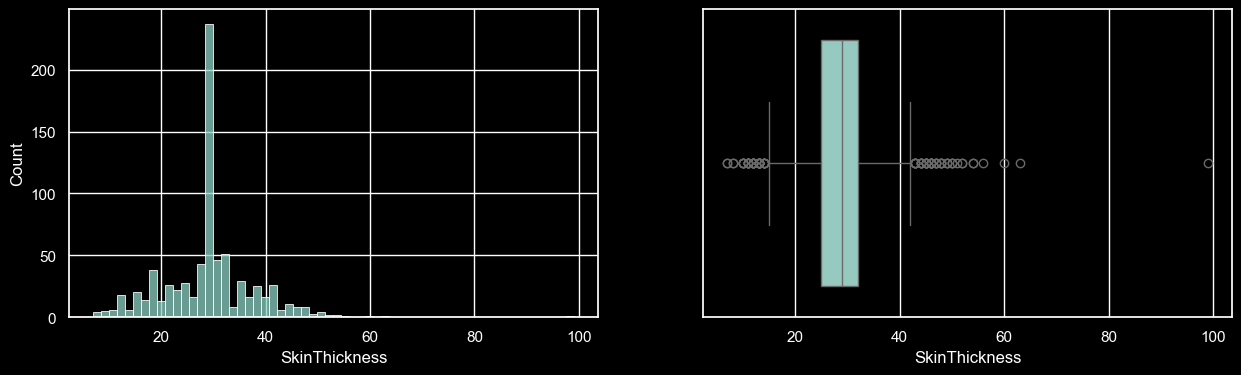

In [79]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 4))
histplot = sns.histplot(data=df, x='SkinThickness', ax=axes[0]);
boxplot = sns.boxplot(data=df, x='SkinThickness', ax=axes[1]);

**Задание 8.8**

Сколько выбросов найдёт классический метод z-отклонения в признаке SkinThickness?

In [82]:
def outliers_z_score(data, feature, log_scale=False):
    if log_scale:
        x = np.log(data[feature]+1)
    else:
        x = data[feature]
    mu = x.mean()
    sigma = x.std()
    lower_bound = mu - 3 * sigma
    upper_bound = mu + 3 * sigma
    outliers = data[(x < lower_bound) | (x > upper_bound)]
    cleaned = data[(x >= lower_bound) & (x <= upper_bound)]
    return outliers, cleaned

In [84]:
outliers, cleaned = outliers_z_score(df, 'SkinThickness')
print(f'Число выбросов по методу z-отклонения: {outliers.shape[0]}')
print(f'Результирующее число записей: {cleaned.shape[0]}')

Число выбросов по методу z-отклонения: 4
Результирующее число записей: 757


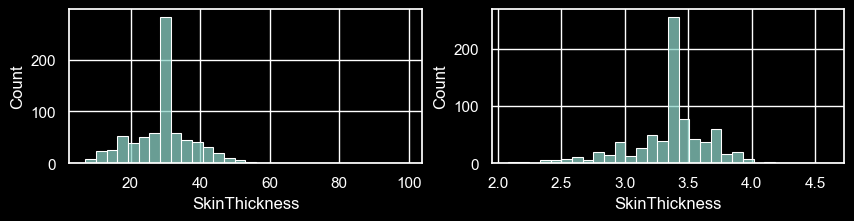

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(10, 2))

#гистограмма исходного признака
histplot = sns.histplot(df['SkinThickness'], bins=30, ax=axes[0])

#гистограмма в логарифмическом масштабе
log_feature = np.log(df['SkinThickness'] + 1)
histplot = sns.histplot(log_feature, bins=30, ax=axes[1]);

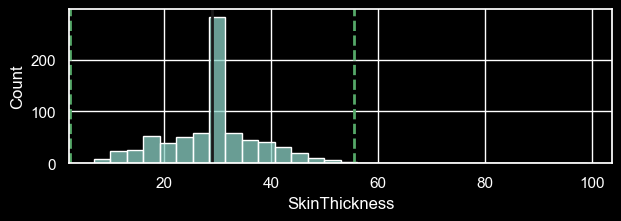

In [97]:
fig, ax = plt.subplots(1, 1, figsize=(7, 2))
feature = df['SkinThickness']
histplot = sns.histplot(feature, bins=30, ax=ax)
histplot.axvline(feature.mean(), color='k', lw=2)
histplot.axvline(feature.mean()+ 3 * feature.std(), color='g', ls='--', lw=2)
histplot.axvline(feature.mean()- 3 * feature.std(), color='g', ls='--', lw=2);

**Задание 8.9**

На приведённой гистограмме показано распределение признака DiabetesPedigreeFunction. Такой вид распределения очень похож на логнормальный, и он заставляет задуматься о логарифмировании признака. Найдите сначала число выбросов в признаке DiabetesPedigreeFunction с помощью классического метода межквартильного размаха.

Затем найдите число выбросов в этом же признаке в логарифмическом масштабе (при логарифмировании единицу прибавлять не нужно!). Какова разница между двумя этими числами (вычтите из первого второе)?

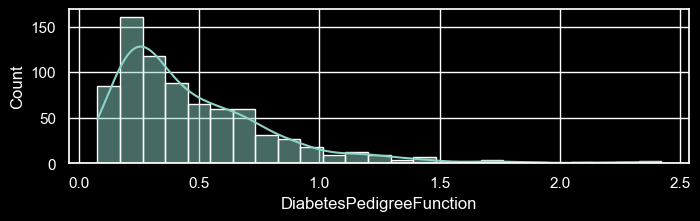

In [101]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(8, 2))
sns.histplot(
    data = df,
    x = 'DiabetesPedigreeFunction',
    bins = 25,
    kde = True,
);

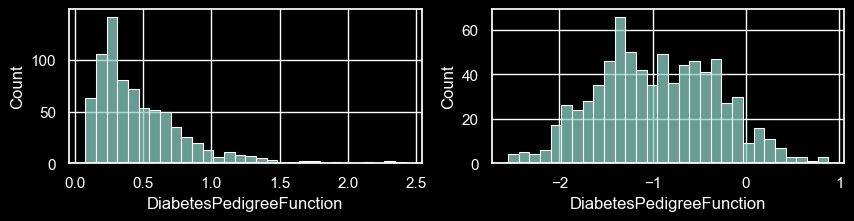

In [112]:
fig, axes = plt.subplots(1, 2, figsize=(10, 2))

#гистограмма исходного признака
histplot = sns.histplot(df['DiabetesPedigreeFunction'], bins=30, ax=axes[0])

#гистограмма в логарифмическом масштабе
log_feature = np.log(df['DiabetesPedigreeFunction'])
histplot = sns.histplot(log_feature, bins=30, ax=axes[1]);

In [104]:
def outliers_iqr_mod(data, feature, left=1.5, right=1.5, log_scale=False, add_one=1):
    if log_scale:
        x = np.log(data[feature] + add_one)
    else:
        x = data[feature]
    quartile_1, quartile_3 = x.quantile(0.25), x.quantile(0.75),
    iqr = quartile_3 - quartile_1
    lower_bound = quartile_1 - (iqr * left)
    upper_bound = quartile_3 + (iqr * right)
    outliers = data[(x < lower_bound) | (x > upper_bound)]
    cleaned = data[(x >= lower_bound) & (x <= upper_bound)]
    return outliers, cleaned

In [105]:
outliers, cleaned = outliers_iqr_mod(df, 'DiabetesPedigreeFunction')
print(f'Число выбросов по методу Тьюки: {outliers.shape[0]}')
print(f'Результирующее число записей: {cleaned.shape[0]}')

Число выбросов по методу Тьюки: 29
Результирующее число записей: 732


In [108]:
outliers, cleaned = outliers_iqr_mod(df, 'DiabetesPedigreeFunction', log_scale=True, add_one=0)
print(f'Число выбросов по методу Тьюки: {outliers.shape[0]}')
print(f'Результирующее число записей: {cleaned.shape[0]}')

Число выбросов по методу Тьюки: 0
Результирующее число записей: 761
